# Exp 1 - To demonstrate confusion matrix using python

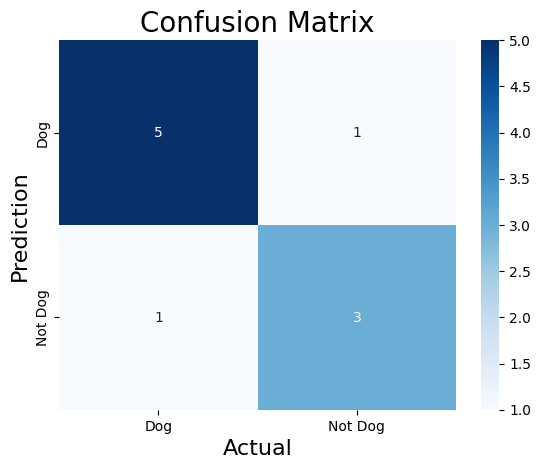

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
actual = np.array(
    ['Dog','Dog','Dog','Not Dog','Dog','Not Dog','Dog','Dog','Not Dog','Not Dog'])
predicted = np.array(
    ['Dog','Not Dog','Dog','Not Dog','Dog','Dog','Dog','Dog','Not Dog','Not Dog'])
conf_matrix = confusion_matrix(actual,predicted)
sns.heatmap(conf_matrix, annot = True, xticklabels = ['Dog','Not Dog'], yticklabels=['Dog', 'Not Dog'], cmap = 'Blues')
plt.ylabel("Prediction", fontsize= 16)
plt.xlabel("Actual", fontsize=16)
plt.title("Confusion Matrix", fontsize = 20)
plt.show()

# Exp 2 - To demonstrate 2 class confusion matrix using python


Accuracy:  0.9743589743589743
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        17
     class_1       0.96      1.00      0.98        22

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39

Precision: 0.96
Recall: 1.00
F1 Score:0.98


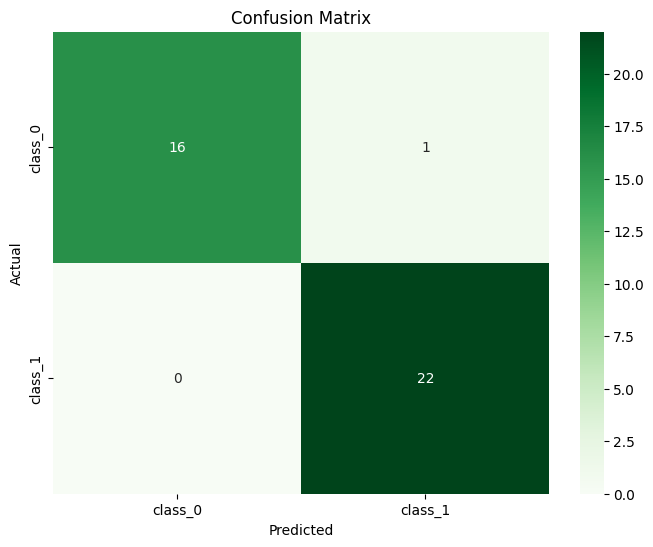

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score,classification_report, confusion_matrix, precision_score
wine= load_wine()
data = pd.DataFrame(data = wine.data, columns = wine.feature_names)
data['target'] = wine.target
data = data[data['target']!=2]
x = data.drop('target', axis = 1)
y = data['target']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state = 1)
model = DecisionTreeClassifier(random_state= 1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

class_report = classification_report(y_test, y_pred, target_names = wine.target_names[:2])
print("Classification Report:\n", class_report)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score:{f1:.2f}")
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (8,6))
sns.heatmap(conf_matrix, annot = True, xticklabels = wine.target_names[:2], yticklabels = wine.target_names[:2], cmap = 'Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Exp - 3: To analyse the the performance of a multiclass confusion matrix by using choosen database with python code


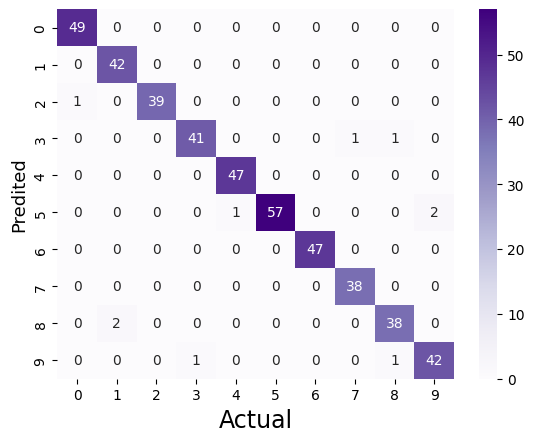

Acuracy 0.9777777777777777


In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
X,y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.25)
model = RandomForestClassifier(random_state=23)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = "Purples")
plt.ylabel("Predited", fontsize = 13)
plt.xlabel("Actual", fontsize = 17)
plt.show()
accuracy = accuracy_score(y_test, y_pred)
print("Acuracy", accuracy)

# Exp - 4: To analyse the performance of a over fitting by using choosen database with python code


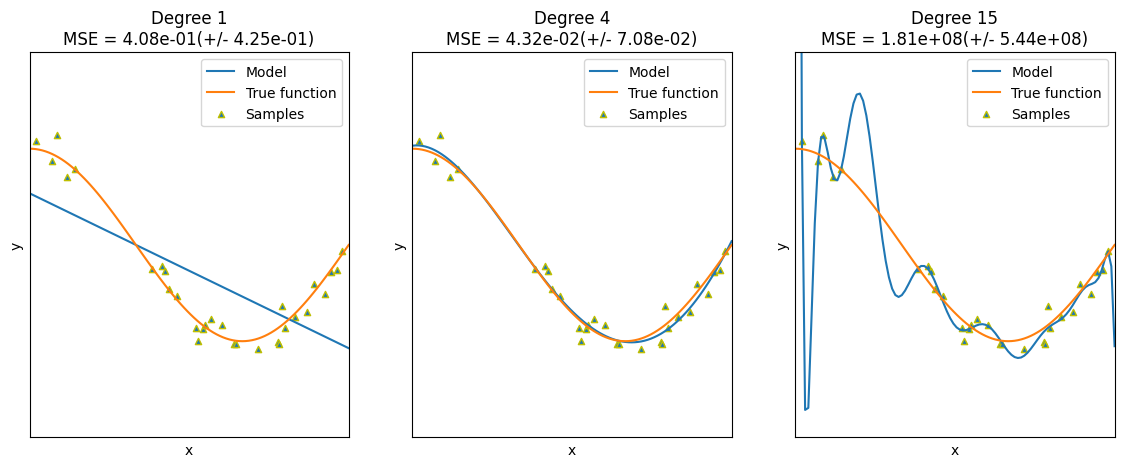

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def true_fun(X):
  return np.cos(1.5*np.pi*X)

np.random.seed(0)
n_samples = 30
degrees = [1,4,15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1
plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
  ax = plt.subplot(1, len(degrees), i + 1)
  plt.setp(ax, xticks=(), yticks=())
  polynomial_features = PolynomialFeatures(degree=degrees[i],include_bias=False)
  linear_regression = LinearRegression()
  pipeline = Pipeline(
      [
          ("polynomial_features", polynomial_features),
           ("linear_regression", linear_regression),
          ]
      )
  pipeline.fit(X[:, np.newaxis], y)
  scores = cross_val_score(pipeline, X[:, np.newaxis], y, scoring="neg_mean_squared_error", cv=10)
  X_test = np.linspace(0, 1, 100)
  plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
  plt.plot(X_test, true_fun(X_test), label="True function")
  plt.scatter(X, y, edgecolor="y", s=20,marker="^", label="Samples")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.xlim((0, 1))
  plt.ylim((-2, 2))
  plt.legend(loc="best")
  plt.title(
  "Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std())
  )
plt.show()




#EXP 5 - To demonstrate the performance of a linear regression by using choosen database with python code

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
Mean Squared Error on test set: 0.23


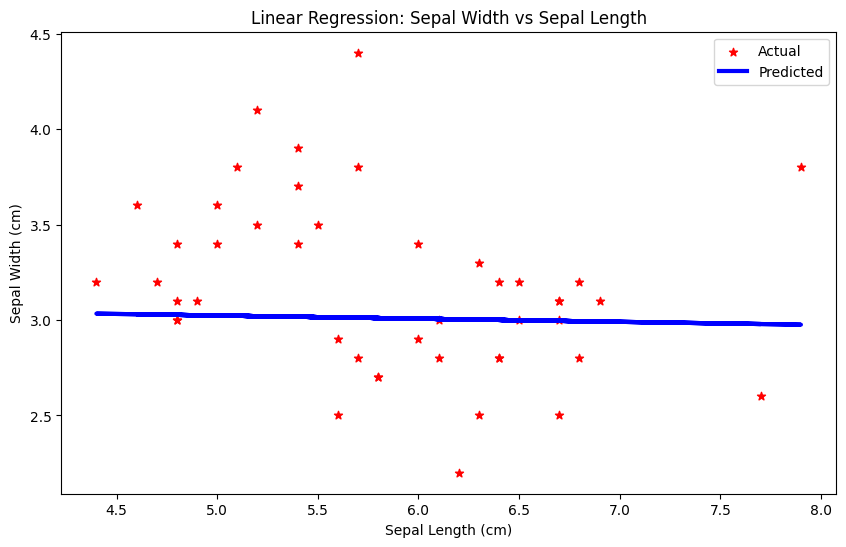

The predicted sepal width for sepal length [[5]] is 3.02 cm


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
print(data.head())
X = data[['sepal length (cm)']]
y = data['sepal width (cm)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on test set: {mse:.2f}')
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='r',marker='*', label='Actual')
plt.plot(X_test, y_pred, color='b', linewidth=3, label='Predicted')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Linear Regression: Sepal Width vs Sepal Length')
plt.legend()
plt.show()

new_sample = pd.DataFrame([[5]], columns=['sepal length (cm)'])
predicted_width = model.predict(new_sample)
print(f'The predicted sepal width for sepal length {new_sample.values.tolist()} is {predicted_width[0]:.2f} cm')

#EXP 6 - To demonstrate the performance of knn using wine dataset

accuracy: 0.7037037037037037


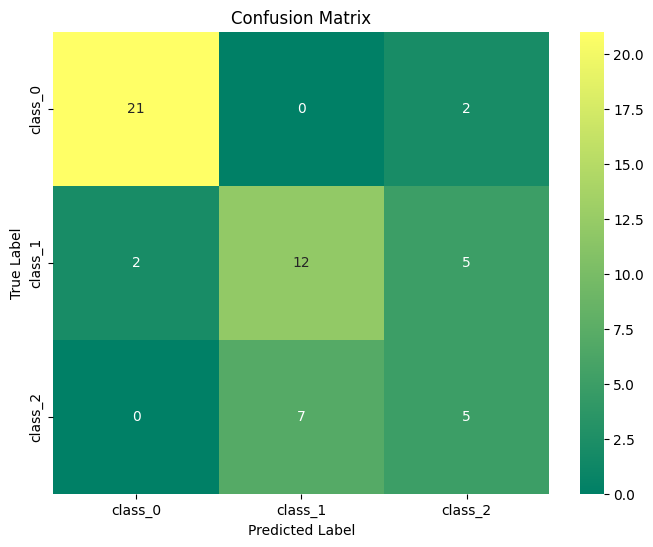

In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
wine=load_wine()
data=pd.DataFrame(data=wine.data,columns=wine.feature_names)
data['Target']=wine.target
x=data.drop('Target',axis=1)
y=data['Target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='summer',
xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#EXP 7 - To demonstrate the performance of a logistic regression by using choosen database with python code.

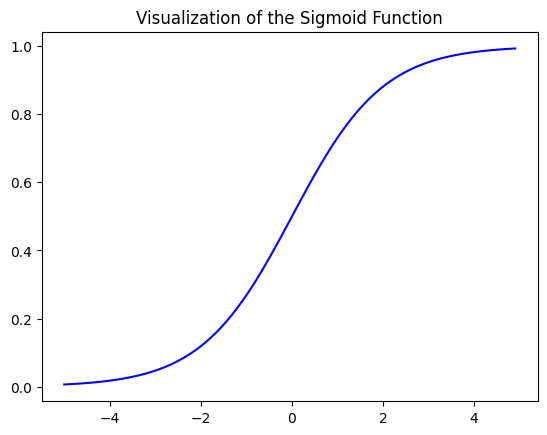

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(z):
  return 1 / (1 + np.exp( - z))
plt.plot(np.arange(-5, 5, 0.1), sigmoid(np.arange(-5, 5, 0.1)),color='blue')
plt.title('Visualization of the Sigmoid Function')
plt.show()

#EXP 8 - To demonstrate the performance of KNN algorithm by using iris dataset

accuracy: 0.9777777777777777


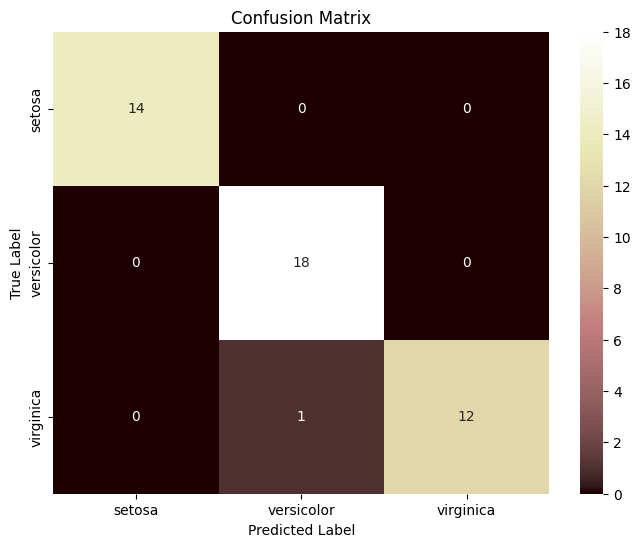

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
iris=load_iris()
data=pd.DataFrame(data=iris.data,columns=iris.feature_names)
data['Species']=iris.target
x=data.drop('Species',axis=1)
y=data['Species']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='pink',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#EXP 9 - To demonstrate the performance of Naïve Bayes algorithm by using iris dataset

accuracy: 0.9777777777777777


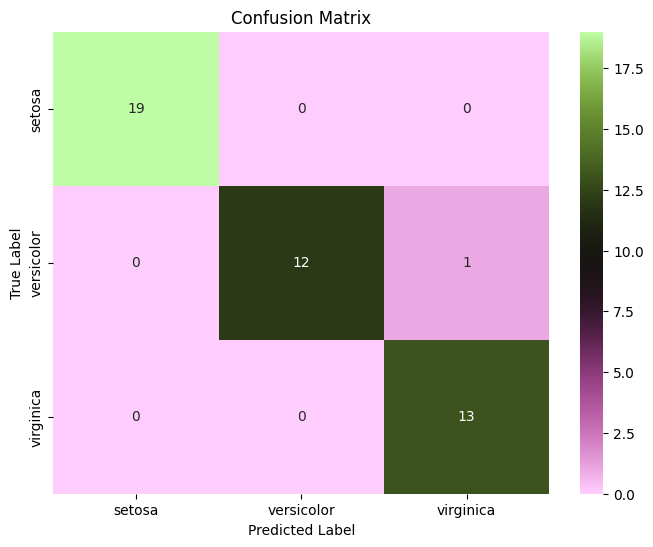

In [ ]:
#naive bayes iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix
iris = load_iris()

data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
X = data.drop('species', axis=1)
y = data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='vanimo',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#EXP 10 - To demonstrate the performance of Logistic Regression using iris dataset

accuracy: 0.9666666666666667


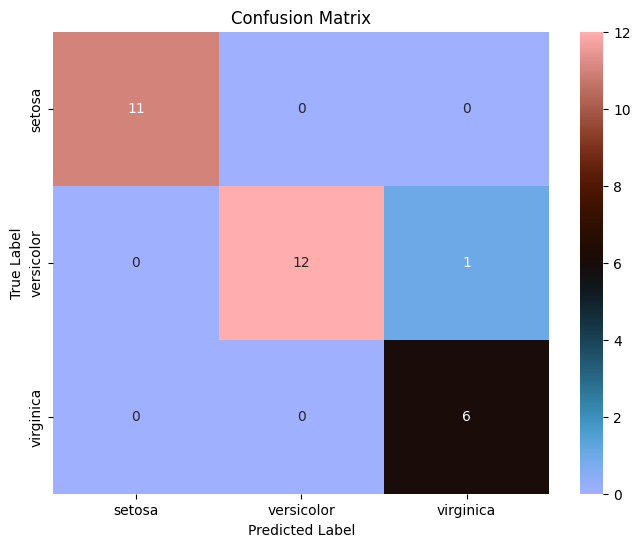

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)

data['species'] = iris.target
X = data.drop('species', axis=1)
y = data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=1)
model =LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='berlin',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#EXP 11 - To demonstrate the performance of Decision tree Classifier algorithm using iris dataset.

accuracy: 0.9666666666666667


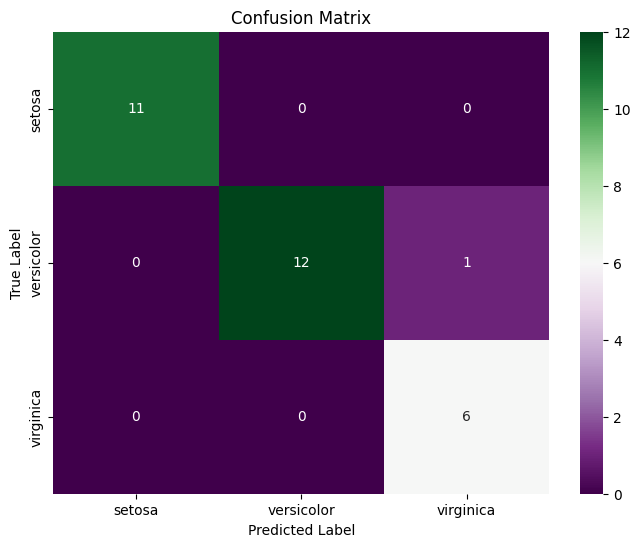

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
iris = load_iris()

data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
X = data.drop('species', axis=1)
y = data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=1)
model =DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='PRGn',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#EXP 12 - To demonstrate the performance of Random Forest classifier algorithm by using iris dataset

accuracy: 0.9555555555555556


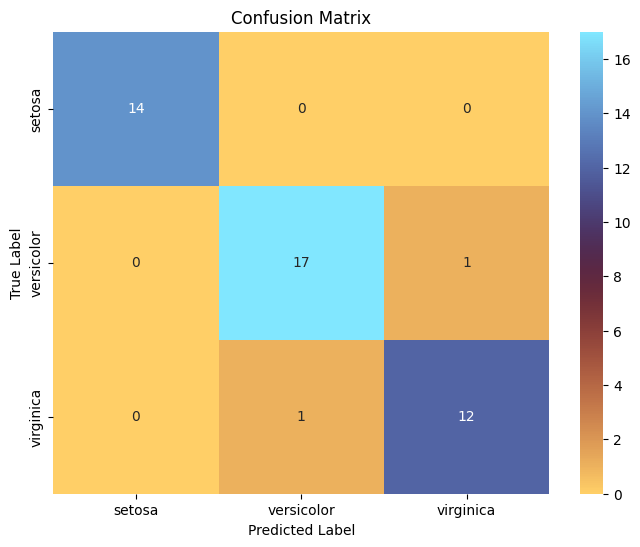

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
iris=load_iris()
data=pd.DataFrame(data=iris.data,columns=iris.feature_names)
data['Species']=iris.target
x=data.drop('Species',axis=1)
y=data['Species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=RandomForestClassifier(n_estimators=100,random_state=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='managua',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')

plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#EXP 13 - To demonstrate the performance of SVM algorithm by using iris dataset

accuracy: 0.9666666666666667


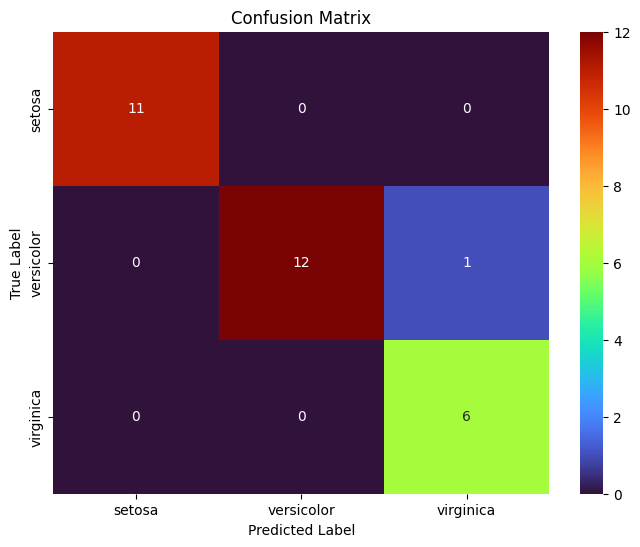

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix
iris=load_iris()
data=pd.DataFrame(data=iris.data,columns=iris.feature_names)
data['Species']=iris.target
x=data.drop('Species',axis=1)
y=data['Species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
model=SVC(kernel='poly',random_state=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='turbo',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Iteration 1: Cost 5031.3015, Weight 0.21744528996901658, Bias 1.3877
Iteration 101: Cost 185.56941123866557, Weight 9.459227106883091, Bias 60.3672282719577
Iteration 201: Cost 100.34293399589959, Weight 10.684868107118445, Bias 68.18906711826675
Iteration 301: Cost 98.84397526476002, Weight 10.847412072256065, Bias 69.22639591234459
Iteration 401: Cost 98.81761165863254, Weight 10.868968580725983, Bias 69.36396599633204


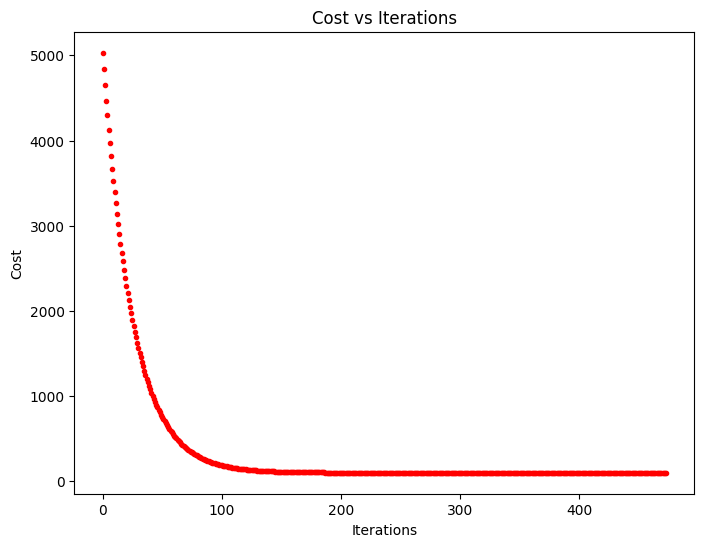

Estimated Weight: 10.87151030998278, Estimated Bias: 69.38018689350649


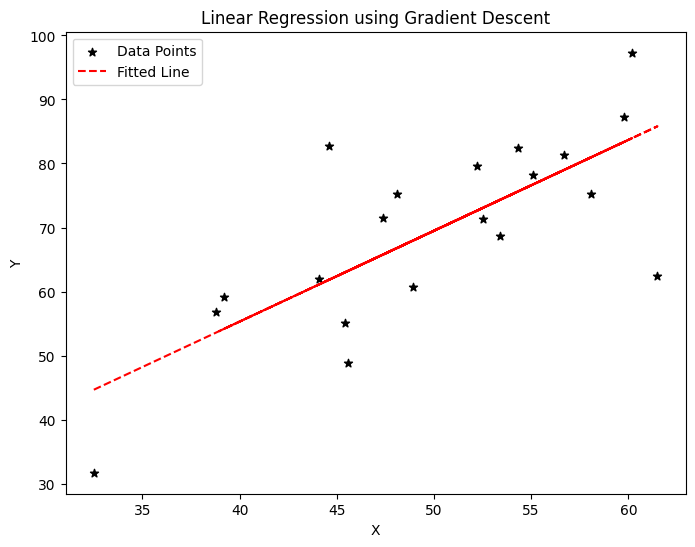

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
def mean_squared_error(y_true, y_predicted):
  cost = np.sum((y_true - y_predicted)**2) / len(y_true)
  return cost
def gradient_descent(x, y, iterations=1000, learning_rate=0.01,stopping_threshold=1e-6):
  current_weight = 0.0
  current_bias = 0.0

  n = float(len(x))
  costs = []
  previous_cost = None
  for i in range(iterations):
    y_predicted = current_weight * x + current_bias
    current_cost = mean_squared_error(y, y_predicted)
    if previous_cost and abs(previous_cost - current_cost) <= stopping_threshold:
      break
    previous_cost = current_cost
    costs.append(current_cost)
    weight_derivative = -(2/n) * sum(x * (y - y_predicted))
    bias_derivative = -(2/n) * sum(y - y_predicted)
    current_weight = current_weight - learning_rate * weight_derivative
    current_bias = current_bias - learning_rate * bias_derivative
    if i % 100 == 0:
      print(f"Iteration {i+1}: Cost {current_cost}, Weight {current_weight}, Bias {current_bias}")
  plt.figure(figsize=(8,6))
  plt.plot(range(len(costs)), costs, 'r.')
  plt.title("Cost vs Iterations")
  plt.xlabel("Iterations")
  plt.ylabel("Cost")
  plt.show()
  return current_weight, current_bias
def main():

  X = np.array([32.5, 53.4, 61.5, 47.4, 59.8, 55.1, 52.2, 39.2, 48.1, 52.5, 45.4, 54.3, 44.1, 58.1, 56.7, 48.9, 44.6, 60.2, 45.6, 38.8])
  Y = np.array([31.7, 68.7, 62.5, 71.5, 87.2, 78.2, 79.6, 59.1, 75.3, 71.3, 55.1, 82.4, 62.0, 75.3, 81.4, 60.7, 82.8, 97.3, 48.8, 56.8])
  scaler = StandardScaler()
  X_normalized = scaler.fit_transform(X.reshape(-1, 1)).flatten()
  estimated_weight, estimated_bias = gradient_descent(X_normalized, Y, iterations=2000, learning_rate=0.01)
  print(f"Estimated Weight: {estimated_weight}, Estimated Bias: {estimated_bias}")
  Y_pred = estimated_weight * X_normalized + estimated_bias
  plt.figure(figsize=(8,6))
  plt.scatter(X, Y, color='black', label='Data Points',marker='*')
  plt.plot(X, Y_pred, color='red', linestyle='--', label='Fitted Line')
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.title("Linear Regression using Gradient Descent")
  plt.legend()
  plt.show()

if __name__ == "__main__":
  main()

#EXP 15 - To demonstrate the segmentation of image using python

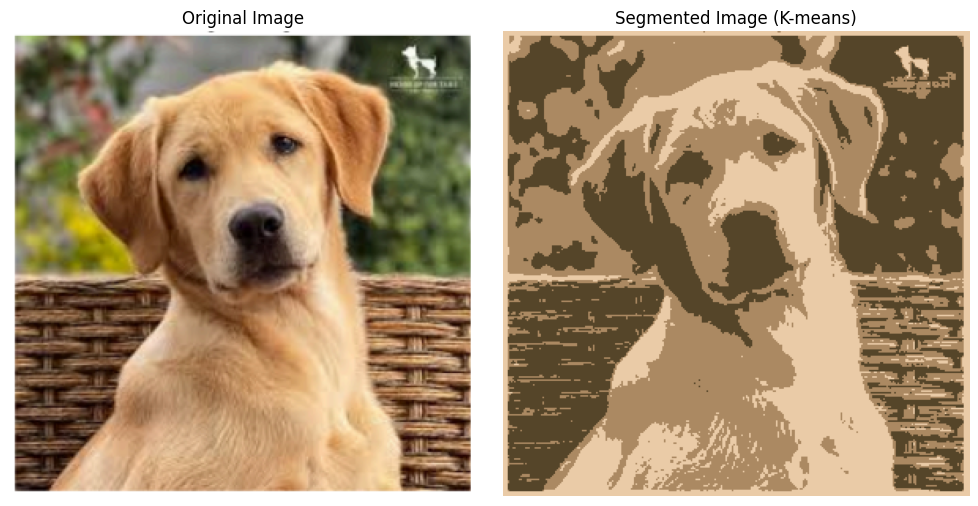

In [13]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the downloaded image
img = cv2.imread('dog.png') # Changed path to the downloaded image

# Check if the image was loaded successfully
if img is None:
  print("Error: Could not load image. Please check the file path.")
else:
  rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  pixels = np.float32(rgb_img.reshape((-1, 3)))
  criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
  K = 3
  _, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
  centers = np.uint8(centers)
  segmented_img = centers[labels.flatten()].reshape(rgb_img.shape)
  plt.figure(figsize=(10, 5))
  plt.subplot(121)
  plt.imshow(rgb_img)
  plt.title('Original Image')
  plt.axis('off')

  plt.subplot(122)
  plt.imshow(segmented_img)
  plt.title('Segmented Image (K-means)')
  plt.axis('off')
  plt.tight_layout()
  plt.show()

#EXP 16 - To demonstrate the segmentation of image using python

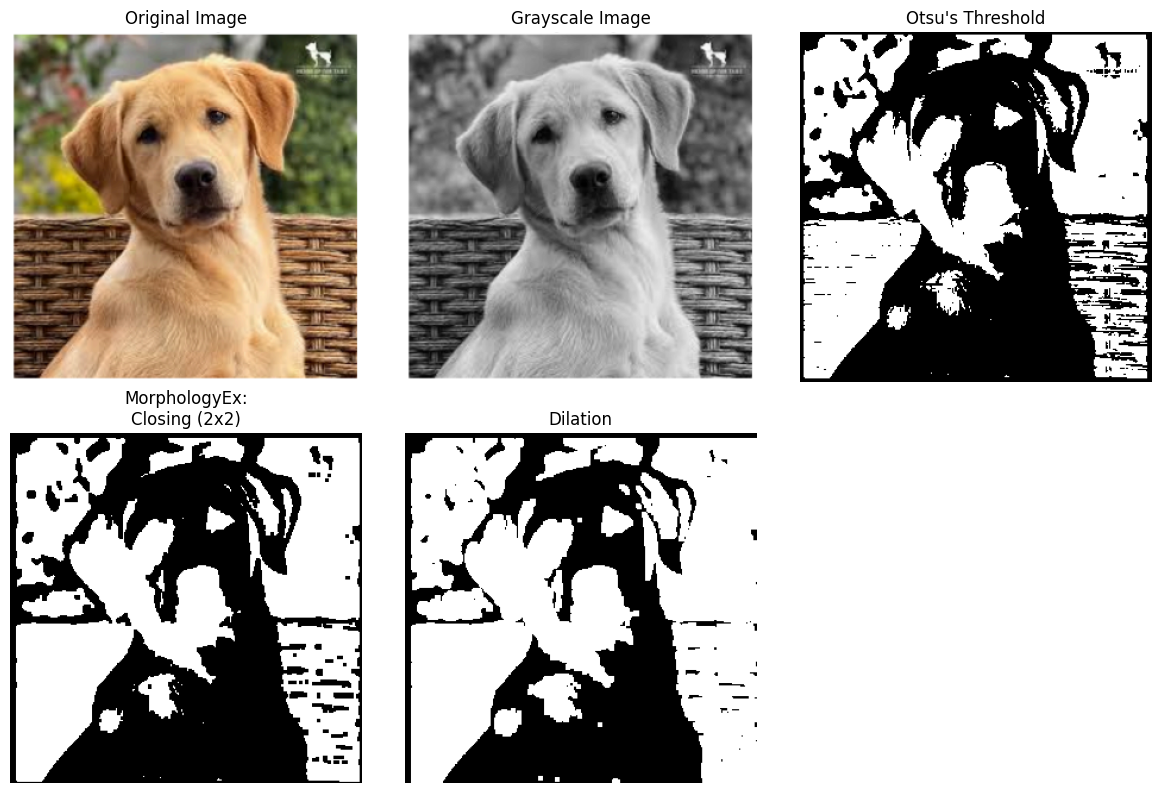

In [17]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('dog.png')

if img is None:
  print("Error: Could not load image. Please check the file path.")
else:
  b, g, r = cv2.split(img)
  rgb_img = cv2.merge([r, g, b])
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
  kernel = np.ones((2, 2), np.uint8)
  closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
  sure_bg = cv2.dilate(closing, kernel, iterations=3)
  plt.figure(figsize=(12, 8))
  plt.subplot(231); plt.imshow(rgb_img); plt.title("Original Image"); plt.axis('off')
  plt.subplot(232); plt.imshow(gray, 'gray'); plt.title("Grayscale Image"); plt.axis('off')
  plt.subplot(233); plt.imshow(thresh, 'gray'); plt.title("Otsu's Threshold"); plt.axis('off')
  plt.subplot(234); plt.imshow(closing, 'gray'); plt.title("MorphologyEx:\nClosing (2x2)"); plt.axis('off')
  plt.subplot(235); plt.imshow(sure_bg, 'gray'); plt.title("Dilation"); plt.axis('off')
  plt.tight_layout()
  plt.show()
  plt.imsave('dilation.png', sure_bg)

#EXP 17 - To demonstrate linear separability using python code

Accuracy: 1.00


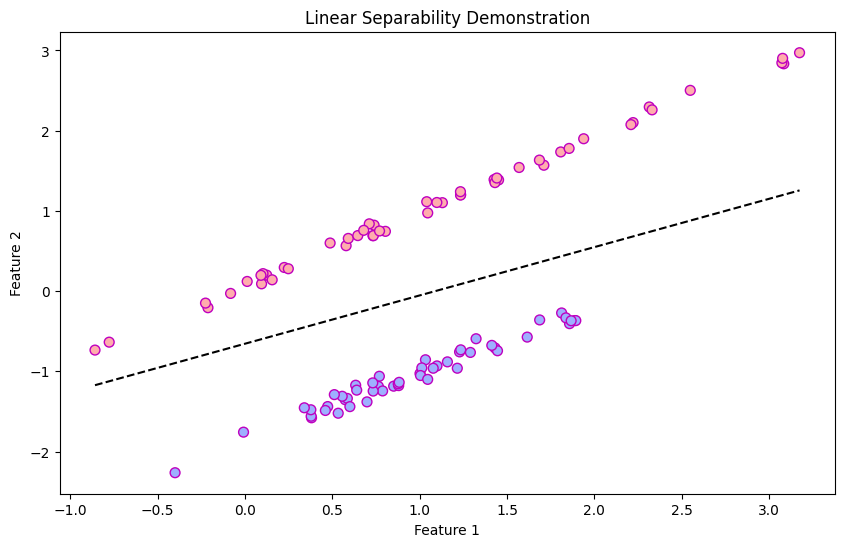

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
model = LogisticRegression()

model.fit(X, y)
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.2f}")
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='berlin', edgecolor='m', s=50)
coef = model.coef_[0]
intercept = model.intercept_
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_vals = - (coef[0] * x_vals + intercept) / coef[1]
plt.plot(x_vals, y_vals, 'k--')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear Separability Demonstration')
plt.show()